In [2]:
from pysus import sinasc
import pandas as pd

estados = [
    "AC","AL","AP","AM","BA","CE","DF","ES","GO",
    "MA","MT","MS","MG","PA","PB","PR","PE","PI",
    "RJ","RN","RS","RO","RR","SC","SP","SE","TO"
]

anos_tentativa = [2022, 2021, 2020, 2019]

dfs = []
ano_usado = {}

for uf in estados:
    for ano in anos_tentativa:
        try:
            df_uf = sinasc(state=uf, year=ano, as_dataframe=True)
            if df_uf.shape[0] > 0:
                df_uf["UF"] = uf
                df_uf["ANO_DADO"] = ano
                dfs.append(df_uf)
                ano_usado[uf] = ano
                print(f"{uf}: {df_uf.shape[0]} linhas (ano {ano})")
                break
        except Exception as e:
            continue

df_brasil = pd.concat(dfs, ignore_index=True)
print("Total:", df_brasil.shape)
print(ano_usado)

AC: 14483 linhas (ano 2022)


AL: 45742 linhas (ano 2022)


AP: 13615 linhas (ano 2022)


AM: 72519 linhas (ano 2022)


BA: 173824 linhas (ano 2022)


...

RR: 13091 linhas (ano 2022)


SC: 98202 linhas (ano 2022)


SP: 525239 linhas (ano 2021)


SE: 28524 linhas (ano 2022)


TO: 22549 linhas (ano 2022)
Total: (2596470, 63)
{'AC': 2022, 'AL': 2022, 'AP': 2022, 'AM': 2022, 'BA': 2022, 'CE': 2022, 'DF': 2022, 'ES': 2022, 'GO': 2022, 'MA': 2022, 'MT': 2022, 'MS': 2022, 'MG': 2019, 'PA': 2022, 'PB': 2022, 'PR': 2022, 'PE': 2022, 'PI': 2022, 'RJ': 2022, 'RN': 2022, 'RS': 2022, 'RO': 2022, 'RR': 2022, 'SC': 2022, 'SP': 2021, 'SE': 2022, 'TO': 2022}


In [4]:
df_brasil["IDADEMAE"] = pd.to_numeric(df_brasil["IDADEMAE"], errors="coerce")

df_brasil["FAIXA_IDADE_MAE"] = pd.cut(
    df_brasil["IDADEMAE"],
    bins=[0, 14, 19, 24, 29, 34, 39, 44, 49, 100],
    labels=["<15", "15-19", "20-24", "25-29", "30-34", "35-39", "40-44", "45-49", "50+"]
)

In [ ]:
prop_adolescentes = (
    df_brasil.groupby("UF")["FAIXA_IDADE_MAE"]
    .apply(lambda x: x.isin(["<15", "15-19"]).mean() * 100)
    .sort_values(ascending=False)
)

df_prop = prop_adolescentes.reset_index()
df_prop.columns = ["UF", "PCT_MAES_ADOLESCENTES"]

df_prop.head()

UF
AC    21.701305
AM    21.143424
PA    20.335156
MA    20.151280
RR    20.151249
AP    18.633860
AL    17.233615
TO    16.723580
PI    14.801051
SE    14.510588
PE    14.484362
MT    14.242982
MS    14.242312
RO    14.208265
PB    14.153502
BA    13.885309
CE    12.634897
RN    12.428504
MG    12.173209
GO    11.814586
RJ    11.161009
ES    11.030563
PR    10.047854
SP     9.346412
RS     8.648774
SC     8.608786
DF     7.932532
Name: FAIXA_IDADE_MAE, dtype: float64


,UF,PCT_MAES_ADOLESCENTES
0,AC,21.701305
1,AM,21.143424
2,PA,20.335156
3,MA,20.151280
4,RR,20.151249


In [ ]:
df_idh = pd.read_excel(r'C:\Users\mateu\OneDrive\Área de Trabalho\Projetos\IDH & Berço — desigualdade regional na maternidade\data\localidade x idh x escolaridade.xlsx')
df_idh.head()

,Territorialidades,Esperança de vida ao nascer 2022,Renda per capita 2022,Subíndice de escolaridade - IDHM Educação 2022,Subíndice de frequência escolar - IDHM Educação 2022,IDHM Educação 2022,IDHM Longevidade 2022,IDHM Renda 2022
0,AC,75.2,530.92,0.653,0.717,0.695,0.837,0.674
1,AL,73.39,493.95,0.586,0.772,0.704,0.807,0.663
2,AP,73.64,534.90,0.735,0.757,0.750,0.811,0.675
3,AM,74.82,520.67,0.733,0.801,0.778,0.830,0.671
4,BA,74.74,518.42,0.613,0.765,0.711,0.829,0.670


: 

In [10]:
df_final = df_prop.merge(
    df_idh,
    left_on="UF",
    right_on="Territorialidades",
    how="left"
)

df_final.head()
df_final.shape

(27, 10)

In [11]:
df_final.corr(numeric_only=True)["PCT_MAES_ADOLESCENTES"].sort_values()

IDHM Renda 2022                                        -0.712525
Renda per capita 2022                                  -0.691203
IDHM Longevidade 2022                                  -0.644127
IDHM Educação 2022                                     -0.387585
Subíndice de frequência escolar - IDHM Educação 2022   -0.382048
Subíndice de escolaridade - IDHM Educação 2022         -0.283920
PCT_MAES_ADOLESCENTES                                   1.000000
Name: PCT_MAES_ADOLESCENTES, dtype: float64

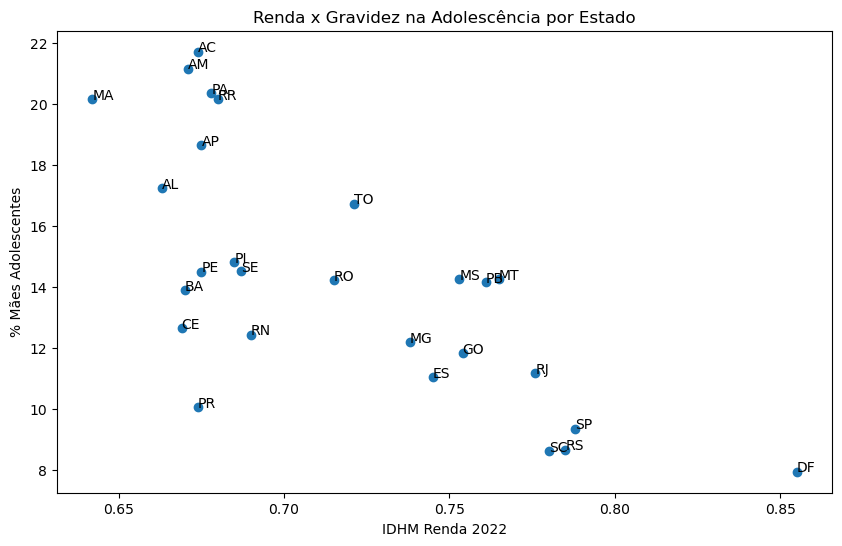

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_final["IDHM Renda 2022"], df_final["PCT_MAES_ADOLESCENTES"])

# Adiciona o nome do estado ao lado de cada ponto
for i, row in df_final.iterrows():
    ax.annotate(row["UF"], (row["IDHM Renda 2022"], row["PCT_MAES_ADOLESCENTES"]))

ax.set_xlabel("IDHM Renda 2022")
ax.set_ylabel("% Mães Adolescentes")
ax.set_title("Renda x Gravidez na Adolescência por Estado")

plt.show()